In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_latency_data(file_path, ignore):
    with open(file_path, "r") as file:
        latencies = [int(line.strip()) for line in file if line.strip().isdigit()]
    n_ignore = int(len(latencies) * ignore)
    latencies = latencies[n_ignore:]
    return latencies


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [2]:
rps_values = [400, 450, 500]

data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
    "relative": [],
}

for rps in rps_values:
    data["rps"].append(rps)

    file_path = f"r{rps}-fcfs.csv"
    tail = get_pctl(read_latency_data(file_path, ignore=0.2), 99)
    data["fcfs"].append(tail)

    file_path = f"r{rps}-masa.csv"
    tail = get_pctl(read_latency_data(file_path, ignore=0.2), 99)
    data["masa"].append(tail)

    data["relative"].append((data["fcfs"][-1] - data["masa"][-1]) / data["fcfs"][-1] * 100)

raw = data
print(raw)

{'rps': [400, 450, 500], 'fcfs': [65416, 80127, 117812], 'masa': [60567, 74393, 103122], 'relative': [7.412559618441971, 7.156139628340011, 12.469018436152513]}


{'rps': [400, 450, 500], 'fcfs': [65.416, 80.127, 117.812], 'masa': [60.567, 74.393, 103.122], 'relative': [7.412559618441971, 7.156139628340011, 12.469018436152513], 'diff': [-4.848999999999997, -5.733999999999995, -14.689999999999998]}


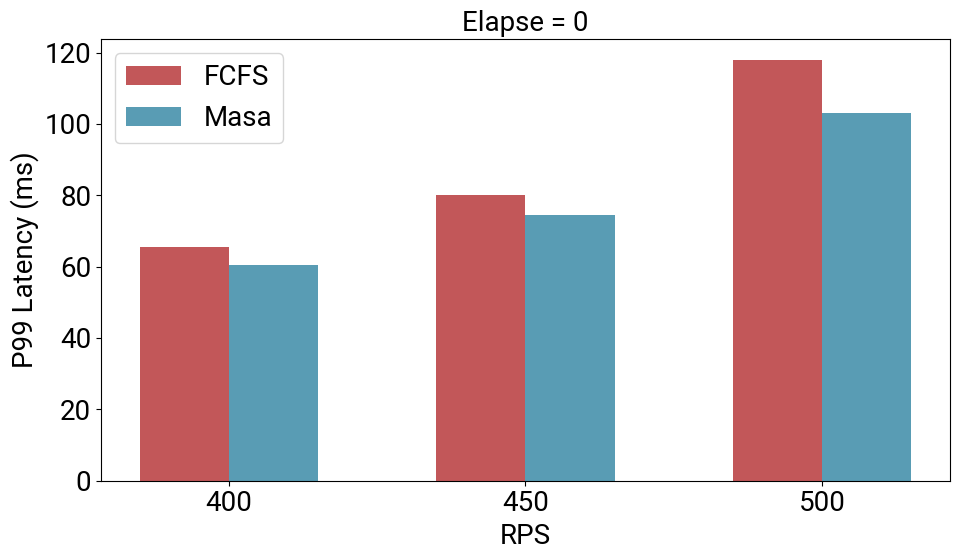

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,  # Sets the base default font size
        "axes.labelsize": 20,  # Font size for x and y labels
        "axes.titlesize": 20,  # Font size for plot title
        "xtick.labelsize": 20,  # Font size for x-axis tick labels
        "ytick.labelsize": 20,  # Font size for y-axis tick labels
        "legend.fontsize": 20,  # Font size for legend
    }
)

data = raw

for key in ["fcfs", "masa"]:
    data[key] = [x / 1e3 for x in data[key]]

data["diff"] = []
for i in range(len(data["rps"])):
    data["diff"].append(data["masa"][i] - data["fcfs"][i])

print(data)

# print(data)

# Setting the positions of the bars on the x-axis
x = np.arange(len(data["rps"]))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2,
    data["fcfs"],
    width,
    label="FCFS",
    color="#C25759",
)
rects2 = ax.bar(
    x + width / 2,
    data["masa"],
    width,
    label="Masa",
    color="#599CB4",
)

# Annotate the bars with the diff
# for i, diff in enumerate(data["diff"]):
#     if diff > 0:
#         text = f"+{diff:.1f}"
#     else:
#         text = f"{diff:.1f}"
#     ax.text(
#         x[i] + width / 2,
#         max(data["fcfs"][i], data["masa"][i]) + 0.2,
#         text,
#         ha="center",
#         va="bottom",
#         color="black",
#         fontsize=18,
#     )

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_title("Elapse = 0")
ax.set_xlabel("RPS")
ax.set_ylabel("P99 Latency (ms)")
# ax.set_ylim(0, 40)
ax.set_xticks(x)
ax.set_xticklabels(data["rps"])
ax.legend()

fig.tight_layout()
plt.savefig("ex0.pdf")
plt.show()